In [10]:
import pandas as pd
from pathlib import Path

In [14]:
base_dir = Path.cwd()
dataset_path = base_dir / "dataset_final_incendies.parquet"

# Read only the needed months to reduce memory usage.
df = pd.read_parquet(
    dataset_path,
    filters=[("MOIS", ">=", 5), ("MOIS", "<=", 10)]
)

In [15]:
df.shape

(18201280, 59)

In [16]:
df.head()

,LAMBX,LAMBY,DATE,ANNEE,MOIS,JOUR,MOIS_NUM,T,FF,HU,...,SER,PENTEXP,ASPERITE,ACCES,INCID,NINCID,ANPYR,DPYR,DIST_MAILLE_M,INCENDIE
0,5400,20810,20150501,2015,5,1,5,12.6,5.8,98.7,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
1,5400,20810,20150502,2015,5,2,5,12.5,3.6,97.2,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
2,5400,20810,20150503,2015,5,3,5,16.1,2.7,88.6,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
3,5400,20810,20150504,2015,5,4,5,18.5,4.0,75.8,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
4,5400,20810,20150505,2015,5,5,5,14.0,4.4,70.3,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0


Undersampling (same logic/seed as the Logistic Regression)

In [17]:
feux = df[df["INCENDIE"] == 1]
pas_feux = df[df["INCENDIE"] == 0].sample(n=len(feux) * 20, random_state=42)
df_reduit = pd.concat([feux, pas_feux]).sample(frac=1, random_state=42)

In [18]:
df_reduit.shape

(371721, 59)

In [ ]:
target_col = "INCENDIE"

In [19]:
# Cell 1: Temporal split on the undersampled dataset + feature column setup
target_col = "INCENDIE"
feature_drop_cols = {target_col, "DATE", "DATEPOINT", "IDP"}
feature_cols = [col for col in df_reduit.columns if col not in feature_drop_cols]

train_df = df_reduit[df_reduit["ANNEE"] <= 2023].reset_index(drop=True)
test_df = df_reduit[df_reduit["ANNEE"] == 2024].reset_index(drop=True)

print("train_df (2015-2023):", train_df.shape, "| Fire:", train_df[target_col].sum())
print("test_df  (2024)     :", test_df.shape, "| Fire:", test_df[target_col].sum())

train_df (2015-2023): (335137, 59) | Fire: 16843
test_df  (2024)     : (36584, 59) | Fire: 858


In [21]:
# Cell 2: Prepare feature matrices and column lists
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].astype(int)
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].astype(int)

numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = [col for col in X_train.columns if col not in numeric_features]

print('Numeric features count:', len(numeric_features))
print('Categorical features count:', len(categorical_features))


Numeric features count: 46
Categorical features count: 9


In [22]:
# Cell 3: Preprocessing pipeline and model definition
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([("imputer", SimpleImputer(strategy="median"))]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]),
            categorical_features,
        ),
    ],
    remainder="drop",
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_leaf=2,
    max_depth=18,
)

model = Pipeline([("preprocess", preprocess), ("rf", rf_model)])

print('Pipeline and model ready')


Pipeline and model ready


In [23]:
# Cell 4: Train the model
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

print('Training rows used:', X_train.shape[0])
print('Evaluation rows used:', X_test.shape[0])
print('Positive rate in training sample:', round(y_train.mean(), 6))
print('Positive rate in evaluation sample:', round(y_test.mean(), 6))

model.fit(X_train, y_train)
print('Model training complete')


Training rows used: 335137
Evaluation rows used: 36584
Positive rate in training sample: 0.050257
Positive rate in evaluation sample: 0.023453
Model training complete


In [25]:
# Cell 5: Evaluate model and assemble results
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, precision_recall_curve, auc

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('\nHoldout metrics on sampled 2024 data:')
print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('Balanced accuracy:', round(balanced_accuracy_score(y_test, y_pred), 4))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba), 4))
print('\nConfusion matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred, zero_division=0))

results_df = test_df[["DATE", "LAMBX", "LAMBY", target_col]].copy()
results_df['fire_probability'] = y_proba
results_df['predicted_fire'] = y_pred

display(results_df.sort_values('fire_probability', ascending=False).head(10))



Holdout metrics on sampled 2024 data:
Accuracy: 0.9569
Balanced accuracy: 0.7681
ROC-AUC: 0.9233

Confusion matrix:
 [[34518  1208]
 [  369   489]]

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98     35726
           1       0.29      0.57      0.38       858

    accuracy                           0.96     36584
   macro avg       0.64      0.77      0.68     36584
weighted avg       0.97      0.96      0.96     36584



,DATE,LAMBX,LAMBY,INCENDIE,fire_probability,predicted_fire
31051,20240704,8280,18490,0,0.973283,1
1379,20240826,8280,18490,1,0.972514,1
26036,20240709,8440,18410,1,0.971177,1
5041,20240703,8200,18250,1,0.970518,1
14712,20240809,8360,18410,1,0.970140,1
12381,20240808,8440,18330,1,0.966571,1
23901,20240717,8440,18330,1,0.965211,1
29595,20240803,8440,18410,1,0.965198,1
8186,20240804,8200,18250,1,0.965106,1
22239,20240713,8440,18250,1,0.964926,1


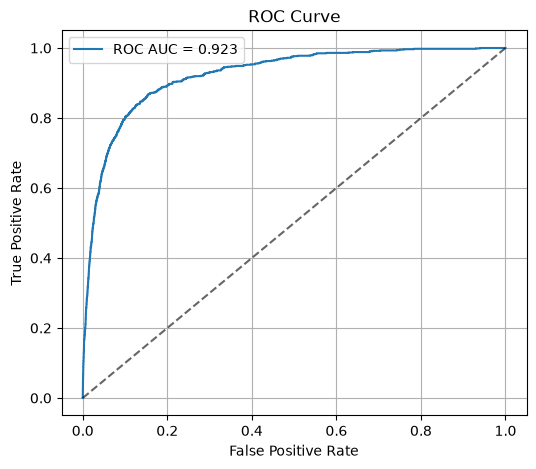

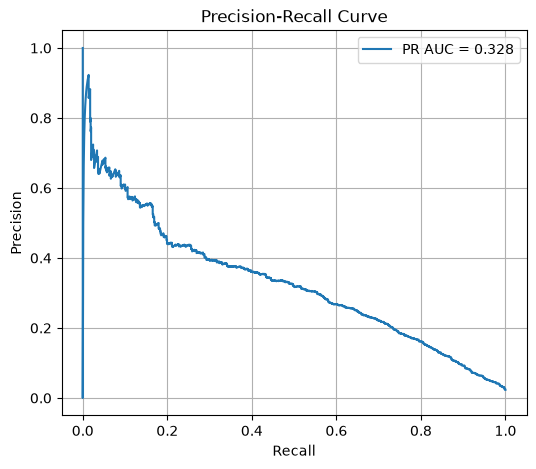

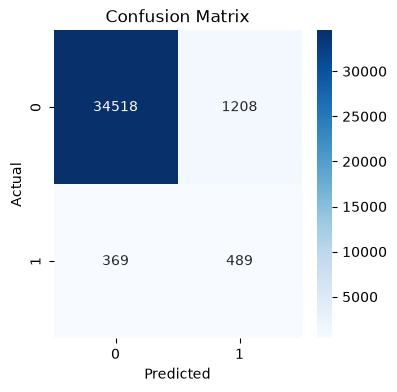

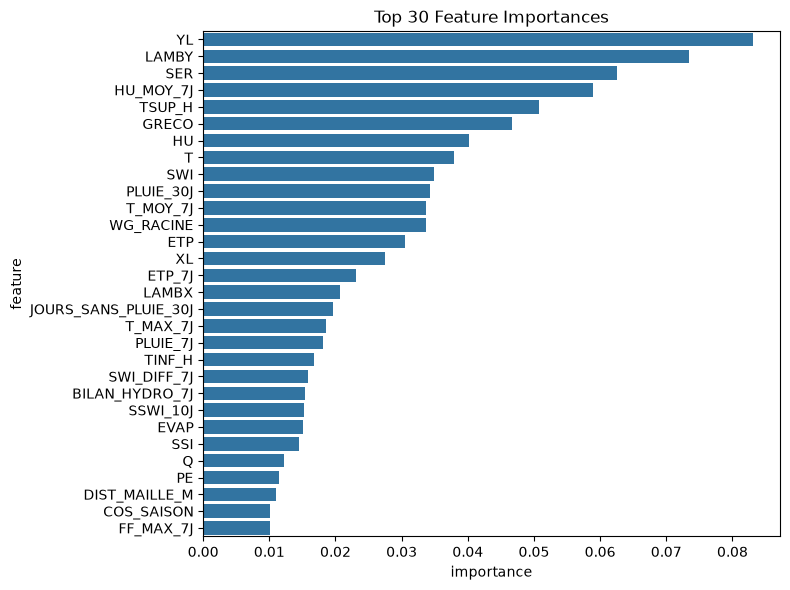

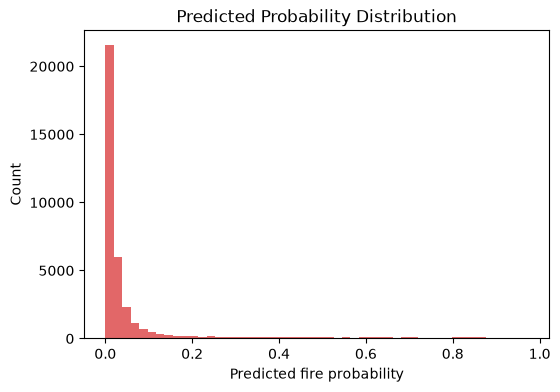

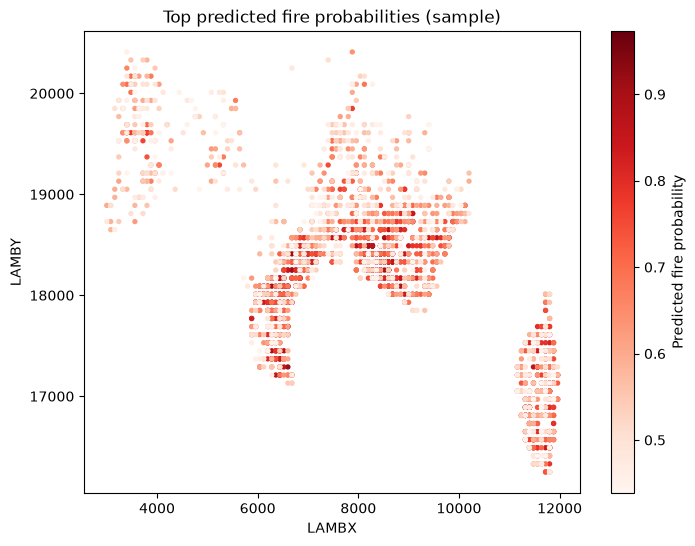

In [27]:
# Cell 6: Visualizations (ROC, PR, confusion matrix, feature importances, maps)
import matplotlib.pyplot as plt
import seaborn as sns

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec, prec)
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, label=f"PR AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importances
feat_names = numeric_features + categorical_features
importances = model.named_steps['rf'].feature_importances_
if len(importances) != len(feat_names):
    feat_names = feat_names[: len(importances)]
imp_df = pd.DataFrame({"feature": feat_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(30)
plt.figure(figsize=(8, 6))
sns.barplot(x="importance", y="feature", data=imp_df)
plt.title("Top 30 Feature Importances")
plt.tight_layout()
plt.show()

# Probability histogram
plt.figure(figsize=(6, 4))
plt.hist(y_proba, bins=50, color="C3", alpha=0.7)
plt.xlabel("Predicted fire probability")
plt.ylabel("Count")
plt.title("Predicted Probability Distribution")
plt.show()

# Geographic scatter of top probabilities (sampled to keep plots manageable)
top_geo = results_df.sort_values("fire_probability", ascending=False).head(2000)
plt.figure(figsize=(8, 6))
plt.scatter(top_geo['LAMBX'], top_geo['LAMBY'], c=top_geo['fire_probability'], cmap='Reds', s=8)
plt.colorbar(label='Predicted fire probability')
plt.xlabel('LAMBX')
plt.ylabel('LAMBY')
plt.title('Top predicted fire probabilities (sample)')
plt.show()
